In [3]:
# Create data from NIST file
with open("./data/chaoskey/chaoskey_additional.bin", "rb") as f:
    data = f.read()

In [4]:
# Split into chunks of 10^6 bits
rois = []
for i in range(0, 250):
    start = int(i * (10**6)/8) # Get correct amount of bytes
    end = int((i+1) * (10**6)/8)
    roi = data[start:end]
    rois.append(roi)

In [4]:
# Convert binary file to plain text format
for i in range(len(rois)):
    roi = rois[i]
    file = f"./data/chaoskey/{i+1:03d}"
    with open(file, "w") as f:
        for j in range(len(roi)):
            if j > 0 and j % 4 == 0:
                f.write("\n")
            f.write(f"{roi[j]:08b}")

In [ ]:
# Evaluate data
import subprocess
for i in range(len(rois)):
    subprocess.run(["cargo", "run", "evaluate", f"--path=./data/chaoskey/{i+1:03d}", f"--out-path=./data/chaoskey/{i+1:03d}-results.json"])

In [5]:
# Evaluate files
import json

contents = []

for i in range(len(rois)):
    file = f"./data/chaoskey/{i+1:03d}-results.json"

    with open(file, "r") as f:
        content = json.load(f)
        
    contents.append(content)

In [6]:
# Combine results
results = dict()

# Create keys
for key in ["monobit_frequency", "block_frequency", "runs", "longest_run",
            "binary_rank", "dft", "non_overlapping", "overlapping", "universal",
            "linear_complexity", "serial", "approximate_entropy", "cusum",
            "random_excursions", "random_excursions_variant", #"universal_cn", "universal_t", "universal_t_cn"
            ]:
    results[key] = []

In [7]:
for content in contents:
    for key, value in content.items():
        match key:
            case "monobit_frequency" | "block_frequency" \
                | "runs" | "longest_run" | \
                "binary_rank" | "dft" \
                | "linear_complexity" | "approximate_entropy":
                results[key].append(value)
            case "non_overlapping" | "serial" | "cusum" \
                | "overlapping" | "random_excursions" | "random_excursions_variant":
                results[key].extend(value)
            case "universal":
                results[key].append(value[0])
                #results["universal_cn"].append(value[1])
                #results["universal_t"].append(value[2])
                #results["universal_t_cn"].append(value[3])

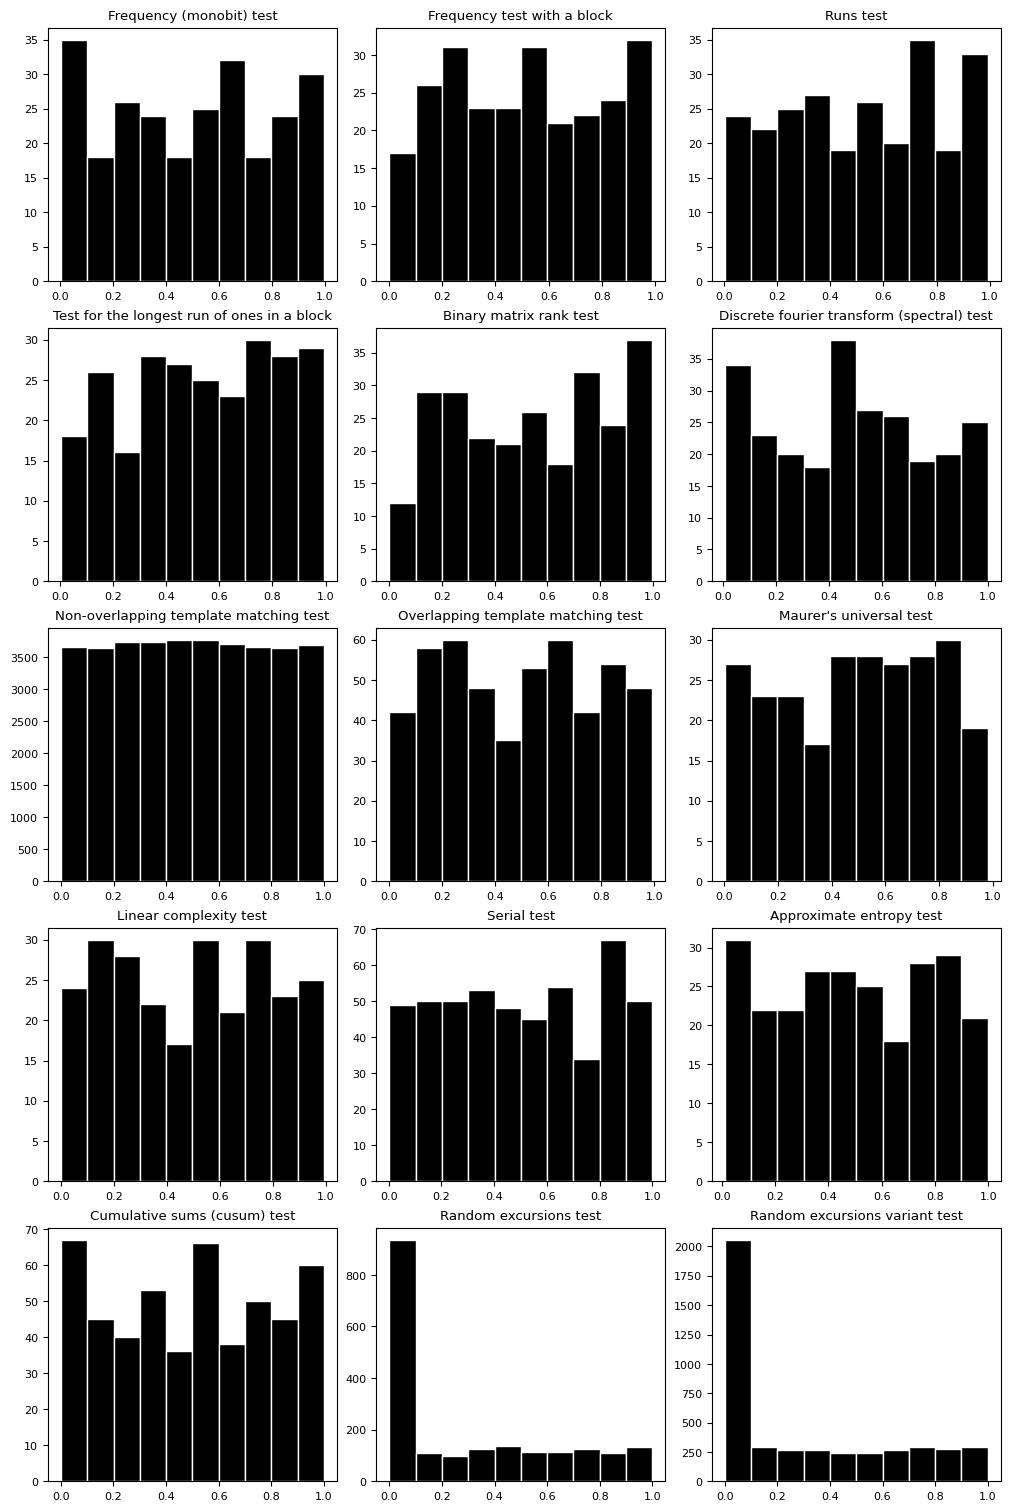

In [8]:
import matplotlib.pyplot as plt

descriptions = {
    "monobit_frequency": "Frequency (monobit) test",
    "block_frequency": "Frequency test with a block",
    "runs": "Runs test",
    "longest_run": "Test for the longest run of ones in a block",
    "binary_rank": "Binary matrix rank test",
    "dft": "Discrete fourier transform (spectral) test",
    "non_overlapping": "Non-overlapping template matching test",
    "overlapping": "Overlapping template matching test",
    "universal": "Maurer's universal test",
    "universal_cn": "Maurer's universal test (CN approx.)",
    "universal_t": "Maurer's universal test (t-test)",
    "universal_t_cn": "Maurer's universal test (CN approx.; t-test)",
    "linear_complexity": "Linear complexity test",
    "serial": "Serial test",
    "approximate_entropy": "Approximate entropy test",
    "cusum": "Cumulative sums (cusum) test",
    "random_excursions": "Random excursions test",
    "random_excursions_variant": "Random excursions variant test"
}
"""
for key in results.keys():
    fig, ax = plt.subplots()
    ax.hist(results[key], bins=10, edgecolor="white")
    ax.set_title(descriptions[key])
    plt.savefig(f"./figures/bbs/{key}.pdf")
"""
font = {"size": 8}
plt.rc("font", **font)

fig, axs = plt.subplots(5, 3, figsize=(10, 15), constrained_layout=True)
i = 0
for key in results.keys():
    row = i % 3
    column = int(i/3)
    axs[column, row].hist(results[key], bins=10, edgecolor="white", color="black")
    axs[column, row].set_title(descriptions[key])
    i += 1
    
plt.savefig(f"./figures/chaoskey.pdf")

In [13]:
# Compute proportions
alpha = 0.01
p = 1- alpha
confidence_min = p - 3 * (((p*(1-p))/300) ** 0.5)
confidence_max = p + 3 * (((p*(1-p))/300) ** 0.5)
print(f"min. confidence: {confidence_min:.4f}, max. confidence: {confidence_max:.4f}")

min. confidence: 0.9728, max. confidence: 1.0072


In [14]:
import numpy as np

# Table header
print("""\\begin{table}[htb]
\t\\centering
\t\\caption{Proportion of sequences passing a test - ChaosKey}
\t\\label{tab:ck-proportions}
\t\\begin{tabular}{|p{7cm}|p{2.1cm}|c|c|}
\t\t\\hline
\t\tTest    &   Accepted observations   &   Proportion &   Result\\\\
\t\t\\hline""")

for key, value in results.items():
    print(f"\t\t{descriptions[key]}", end=" & ")
    
    # Compute proportion
    observations = np.array(value)
    accepted_p_values = (observations >= alpha).sum()
    proportion = accepted_p_values / len(observations)
    print(f"{accepted_p_values}/{len(observations)}", end=" & ")
    print(f"{proportion:.4f}", end=" & ")
    
    if confidence_min <= proportion <= confidence_max:
        print("accepted", end="\\\\\n")
    else:
        print("\\textbf{rejected}", end="\\\\\n")
        
    print("\t\t\\hline")
    
# Table footer
print("""\t\\end{tabular}
\\end{table}""")

\begin{table}[htb]
	\centering
	\caption{Proportion of sequences passing a test - ChaosKey}
	\label{tab:ck-proportions}
	\begin{tabular}{|p{7cm}|p{2.1cm}|c|c|}
		\hline
		Test    &   Accepted observations   &   Proportion &   Result\\
		\hline
		Frequency (monobit) test & 245/250 & 0.9800 & accepted\\
		\hline
		Frequency test with a block & 249/250 & 0.9960 & accepted\\
		\hline
		Runs test & 247/250 & 0.9880 & accepted\\
		\hline
		Test for the longest run of ones in a block & 248/250 & 0.9920 & accepted\\
		\hline
		Binary matrix rank test & 249/250 & 0.9960 & accepted\\
		\hline
		Discrete fourier transform (spectral) test & 245/250 & 0.9800 & accepted\\
		\hline
		Non-overlapping template matching test & 36664/37000 & 0.9909 & accepted\\
		\hline
		Overlapping template matching test & 496/500 & 0.9920 & accepted\\
		\hline
		Maurer's universal test & 247/250 & 0.9880 & accepted\\
		\hline
		Linear complexity test & 248/250 & 0.9920 & accepted\\
		\hline
		Serial test & 498/500 & 0

In [15]:
import scipy

# Table header
print("""\\begin{table}[htb]
\t\\centering
\t\\caption{Uniform distribution of p-values - ChaosKey}
\t\\label{tab:ck-uniform}
\t\\begin{tabular}{|p{7cm}|p{2.1cm}|c|c|}
\t\t\\hline
\t\tTest    &   $\\chi^2$-value   &   p-value &   Result\\\\
\t\t\\hline""")

# Perform goodness-of-fit X^2-test
for key, value in results.items():
    print(f"\t\t{descriptions[key]}", end=" & ")
    
    chi2 = 0.0
    observations = np.array(value)
    expected = len(value) / 10
    
    for i in range(10):
        # Range of accepted items
        min_ = i / 10
        max_ = min_ + 0.1
        accepted_number_p_values = ((observations >= min_) & (observations < max_)).sum()
        chi2 += (accepted_number_p_values - expected) ** 2
    
    # Compute chi-square
    chi2 /= expected
    print(f"{chi2:.4f}", end=" & ")
    pvalue = scipy.special.gammaincc(4.5, chi2/2)
    print(f"{pvalue:.4f}", end=" & ")
    
    if pvalue >= 0.0001:
        print("accepted", end="\\\\\n")
    else:
        print("\\textbf{rejected}", end="\\\\\n")
    print("\t\t\\hline")
    
# Table footer
print("""\t\\end{tabular}
\\end{table}""")

\begin{table}[htb]
	\centering
	\caption{Uniform distribution of p-values - ChaosKey}
	\label{tab:ck-uniform}
	\begin{tabular}{|p{7cm}|p{2.1cm}|c|c|}
		\hline
		Test    &   $\chi^2$-value   &   p-value &   Result\\
		\hline
		Frequency (monobit) test & 10.8000 & 0.2897 & accepted\\
		\hline
		Frequency test with a block & 6.9600 & 0.6413 & accepted\\
		\hline
		Runs test & 8.2400 & 0.5102 & accepted\\
		\hline
		Test for the longest run of ones in a block & 7.6000 & 0.5749 & accepted\\
		\hline
		Binary matrix rank test & 15.9200 & 0.0686 & accepted\\
		\hline
		Discrete fourier transform (spectral) test & 13.6000 & 0.1373 & accepted\\
		\hline
		Non-overlapping template matching test & 6.6519 & 0.6733 & accepted\\
		\hline
		Overlapping template matching test & 11.5600 & 0.2393 & accepted\\
		\hline
		Maurer's universal test & 9.6000 & 0.3838 & accepted\\
		\hline
		Linear complexity test & 6.4800 & 0.6911 & accepted\\
		\hline
		Serial test & 12.0000 & 0.2133 & accepted\\
		\hline
		